# BSM Analytical Greeks

This notebook demonstrates the seven first- and second-order Greeks implemented in `foureng.analytics.bsm_greeks`.

| Greek | Symbol | Formula |
|-------|--------|---------|
| Delta  | $\Delta$ | $\partial V/\partial S$ |
| Gamma  | $\Gamma$ | $\partial^2 V/\partial S^2$ |
| Vega   | $\mathcal{V}$ | $\partial V/\partial \sigma$ |
| Theta  | $\Theta$ | $\partial V/\partial t$ |
| Rho    | $\rho$ | $\partial V/\partial r \div 100$ |
| Vanna  | — | $\partial^2 V/(\partial S\,\partial\sigma)$ |
| Volga  | — | $\partial^2 V/\partial\sigma^2$ |

**Reference**: Hull, *Options, Futures, and Other Derivatives*, 10th ed., Ch. 19.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from foureng.analytics.bsm_greeks import (
    bsm_delta, bsm_gamma, bsm_vega, bsm_theta,
    bsm_rho, bsm_vanna, bsm_volga, bsm_all_greeks,
)
from foureng.analytics.bsm_barrier import bsm_call, bsm_put

# Base parameters
S0, K, r, q, T, sigma = 100.0, 100.0, 0.05, 0.02, 1.0, 0.20
print(f'Base: S={S0}, K={K}, r={r}, q={q}, T={T}, sigma={sigma}')
print()
greeks = bsm_all_greeks(S0, K, r, q, T, sigma, cp=1)
print('ATM call Greeks:')
for name, val in greeks.items():
    print(f'  {name:6s}: {val:.6f}')

Base: S=100.0, K=100.0, r=0.05, q=0.02, T=1.0, sigma=0.2

ATM call Greeks:
  delta : 0.586851
  gamma : 0.018951
  vega  : 37.901158
  theta : -5.089319
  rho   : 0.494581
  vanna : -0.094753
  volga : 2.368822


---
## 1. Greeks vs Spot (S sweep)

We hold K, r, q, T, σ fixed and vary S to show how each Greek evolves across moneyness.

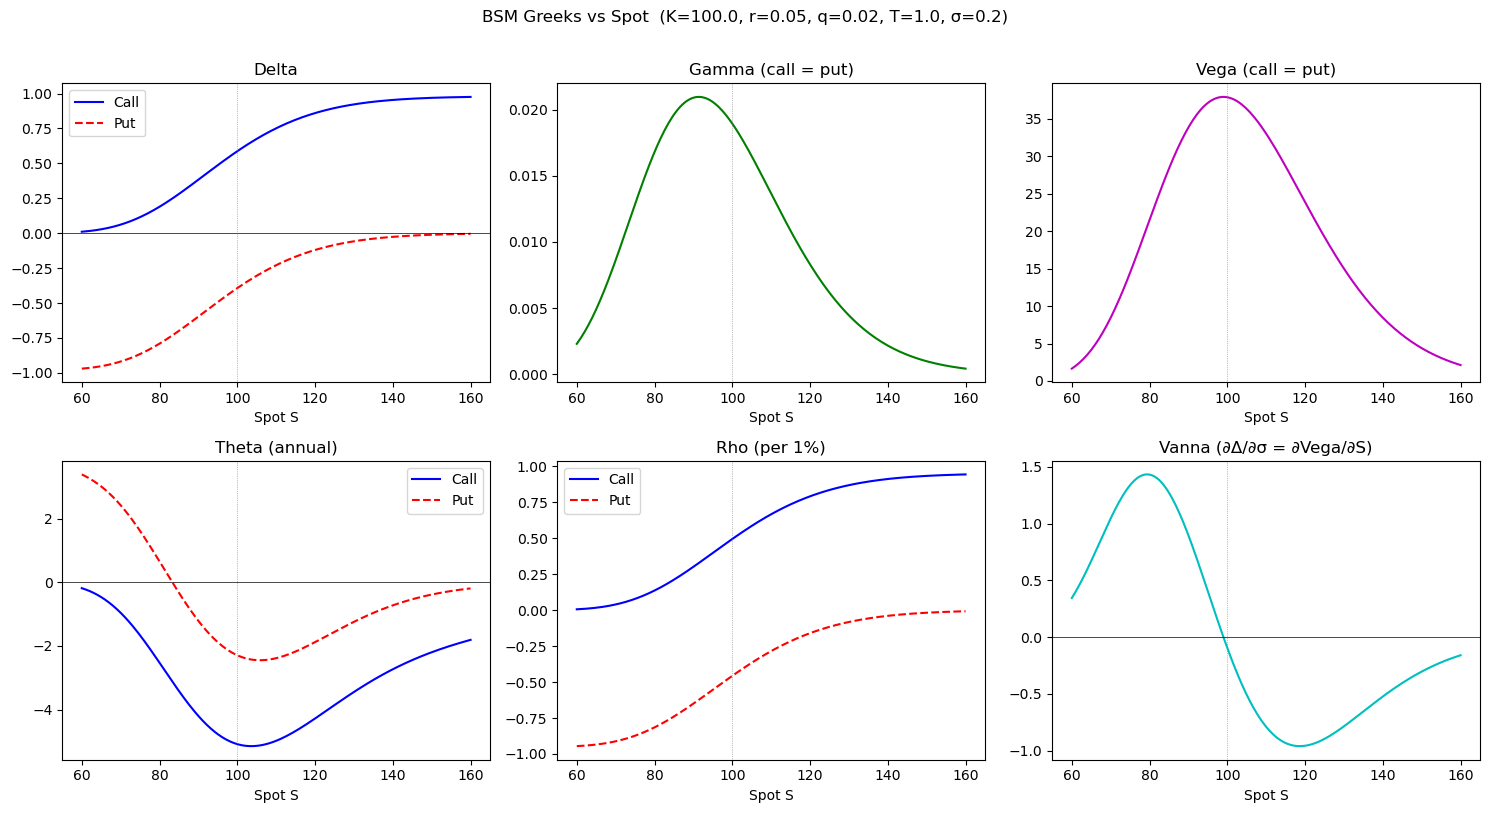

In [2]:
S_range = np.linspace(60, 160, 200)

# Compute Greeks for calls and puts
call_delta = [bsm_delta(s, K, r, q, T, sigma, cp=1)  for s in S_range]
put_delta  = [bsm_delta(s, K, r, q, T, sigma, cp=-1) for s in S_range]
gamma      = [bsm_gamma(s, K, r, q, T, sigma)        for s in S_range]
vega       = [bsm_vega(s, K, r, q, T, sigma)         for s in S_range]
call_theta = [bsm_theta(s, K, r, q, T, sigma, cp=1)  for s in S_range]
put_theta  = [bsm_theta(s, K, r, q, T, sigma, cp=-1) for s in S_range]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].plot(S_range, call_delta, 'b-', label='Call')
axes[0,0].plot(S_range, put_delta,  'r--', label='Put')
axes[0,0].axhline(0, color='k', lw=0.5); axes[0,0].axvline(K, color='gray', lw=0.5, ls=':')
axes[0,0].set_title('Delta'); axes[0,0].legend()

axes[0,1].plot(S_range, gamma, 'g-')
axes[0,1].axvline(K, color='gray', lw=0.5, ls=':')
axes[0,1].set_title('Gamma (call = put)')

axes[0,2].plot(S_range, vega, 'm-')
axes[0,2].axvline(K, color='gray', lw=0.5, ls=':')
axes[0,2].set_title('Vega (call = put)')

axes[1,0].plot(S_range, call_theta, 'b-', label='Call')
axes[1,0].plot(S_range, put_theta,  'r--', label='Put')
axes[1,0].axhline(0, color='k', lw=0.5); axes[1,0].axvline(K, color='gray', lw=0.5, ls=':')
axes[1,0].set_title('Theta (annual)'); axes[1,0].legend()

call_rho = [bsm_rho(s, K, r, q, T, sigma, cp=1)  for s in S_range]
put_rho  = [bsm_rho(s, K, r, q, T, sigma, cp=-1) for s in S_range]
axes[1,1].plot(S_range, call_rho, 'b-', label='Call')
axes[1,1].plot(S_range, put_rho,  'r--', label='Put')
axes[1,1].axvline(K, color='gray', lw=0.5, ls=':')
axes[1,1].set_title('Rho (per 1%)'); axes[1,1].legend()

vanna = [bsm_vanna(s, K, r, q, T, sigma) for s in S_range]
axes[1,2].plot(S_range, vanna, 'c-')
axes[1,2].axhline(0, color='k', lw=0.5); axes[1,2].axvline(K, color='gray', lw=0.5, ls=':')
axes[1,2].set_title('Vanna (∂Δ/∂σ = ∂Vega/∂S)')

for ax in axes.flat:
    ax.set_xlabel('Spot S')
plt.suptitle(f'BSM Greeks vs Spot  (K={K}, r={r}, q={q}, T={T}, σ={sigma})', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Greeks vs Maturity (T sweep)

ATM (S=K=100) — how Greeks evolve as time to expiry shrinks.

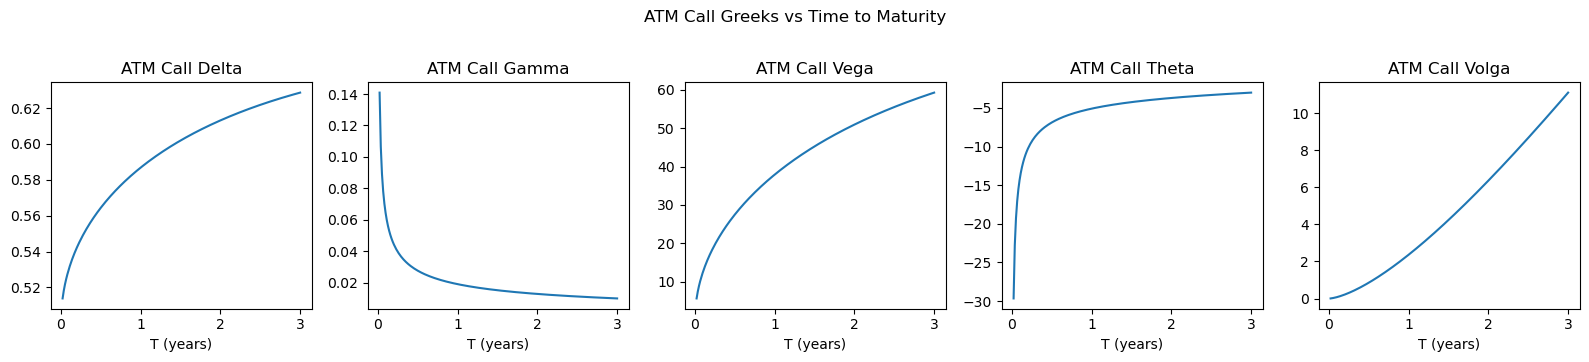


Note: Gamma and Vega both peak at short maturities for ATM options (pin risk).
Theta magnitude increases as expiry approaches — "time value burns faster".


In [3]:
T_range = np.linspace(0.02, 3.0, 200)

delta_T  = [bsm_delta(S0, K, r, q, t, sigma) for t in T_range]
gamma_T  = [bsm_gamma(S0, K, r, q, t, sigma) for t in T_range]
vega_T   = [bsm_vega( S0, K, r, q, t, sigma) for t in T_range]
theta_T  = [bsm_theta(S0, K, r, q, t, sigma) for t in T_range]
volga_T  = [bsm_volga(S0, K, r, q, t, sigma) for t in T_range]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, vals, title in zip(axes,
    [delta_T, gamma_T, vega_T, theta_T, volga_T],
    ['Delta', 'Gamma', 'Vega', 'Theta', 'Volga']):
    ax.plot(T_range, vals)
    ax.set_xlabel('T (years)')
    ax.set_title(f'ATM Call {title}')
plt.suptitle('ATM Call Greeks vs Time to Maturity', y=1.02)
plt.tight_layout()
plt.show()

print('\nNote: Gamma and Vega both peak at short maturities for ATM options (pin risk).')
print('Theta magnitude increases as expiry approaches — "time value burns faster".')

---
## 3. Greeks vs Volatility (σ sweep)

How call Greeks change with implied vol, ATM at T=1.

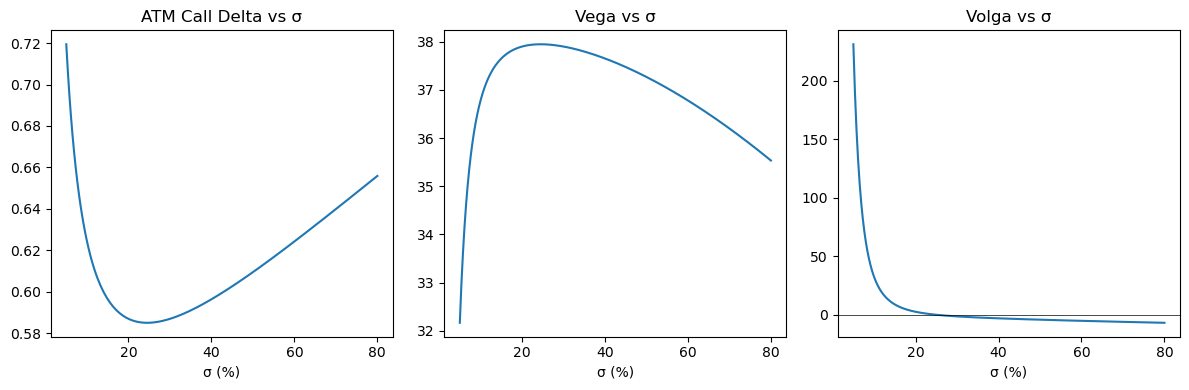

ATM Delta → 0.5 as σ → 0 (deterministic case — option is either deep ITM or OTM)
Volga peaks at low vol and decays — low-vol options have high second-order vol risk.


In [4]:
sig_range = np.linspace(0.05, 0.80, 200)

delta_sig = [bsm_delta(S0, K, r, q, T, s) for s in sig_range]
vega_sig  = [bsm_vega( S0, K, r, q, T, s) for s in sig_range]
volga_sig = [bsm_volga(S0, K, r, q, T, s) for s in sig_range]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(sig_range * 100, delta_sig)
axes[0].set_xlabel('σ (%)'); axes[0].set_title('ATM Call Delta vs σ')

axes[1].plot(sig_range * 100, vega_sig)
axes[1].set_xlabel('σ (%)'); axes[1].set_title('Vega vs σ')

axes[2].plot(sig_range * 100, volga_sig)
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_xlabel('σ (%)'); axes[2].set_title('Volga vs σ')

plt.tight_layout()
plt.show()

print('ATM Delta → 0.5 as σ → 0 (deterministic case — option is either deep ITM or OTM)')
print('Volga peaks at low vol and decays — low-vol options have high second-order vol risk.')

---
## 4. BSM PDE Verification

The Greeks satisfy the BSM PDE:

$$\Theta + \frac{1}{2}\sigma^2 S^2\,\Gamma + (r-q)S\,\Delta - r V = 0$$

We verify this numerically across a grid.

Max |BSM PDE residual|: 2.11e-15
Mean |residual|:        5.45e-16


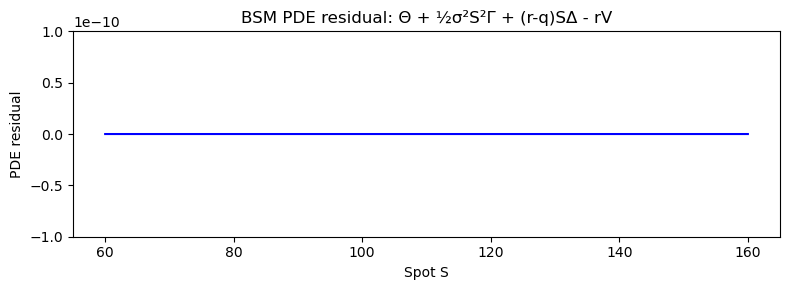

In [5]:
S_grid = np.linspace(60, 160, 50)
errors = []
for s in S_grid:
    V = bsm_call(s, K, r, q, T, sigma)
    θ = bsm_theta(s, K, r, q, T, sigma, cp=1)
    Δ = bsm_delta(s, K, r, q, T, sigma, cp=1)
    Γ = bsm_gamma(s, K, r, q, T, sigma, cp=1)
    pde_residual = θ + 0.5 * sigma**2 * s**2 * Γ + (r - q) * s * Δ - r * V
    errors.append(pde_residual)

errors = np.array(errors)
print(f'Max |BSM PDE residual|: {np.max(np.abs(errors)):.2e}')
print(f'Mean |residual|:        {np.mean(np.abs(errors)):.2e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(S_grid, errors, 'b-', lw=1.5)
ax.set_xlabel('Spot S')
ax.set_ylabel('PDE residual')
ax.set_title('BSM PDE residual: Θ + ½σ²S²Γ + (r-q)SΔ - rV')
ax.set_ylim(-1e-10, 1e-10)
plt.tight_layout()
plt.show()

---
## 5. Delta Hedging P&L simulation

We simulate discrete delta-hedging of a short call position.  
The residual P&L (hedging error) vanishes as the rebalancing frequency increases.

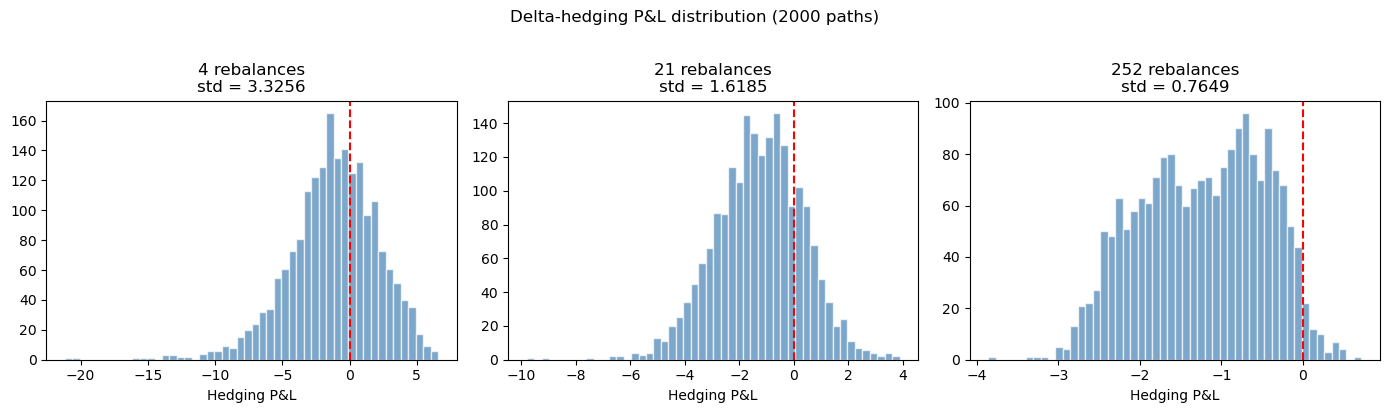

Hedging error std decreases as √(1/n_steps) — continuous hedging is perfect.


In [6]:
def simulate_delta_hedge(S0, K, r, q, T, sigma, n_steps, n_paths=2000, seed=42):
    """Return hedging P&L distribution for a short delta-hedged call."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    disc = np.exp(-r * T)

    S = np.full(n_paths, S0)
    portfolio = np.zeros(n_paths)  # hedging portfolio value

    # Short call premium at inception → invest in risk-free
    V0 = bsm_call(S0, K, r, q, T, sigma)
    portfolio += V0  # receive premium

    # Hedge with delta shares each period
    t = 0.0
    delta_shares = np.zeros(n_paths)
    for step in range(n_steps):
        t_rem = T - t
        t_rem = max(t_rem, 1e-10)
        delta_now = bsm_delta(S, K, r, q, t_rem, sigma, cp=1)
        delta_chg = delta_now - delta_shares
        portfolio -= delta_chg * S   # buy/sell hedge
        delta_shares = delta_now

        # Evolve S and portfolio
        Z = rng.standard_normal(n_paths)
        S = S * np.exp((r - q - 0.5 * sigma**2) * dt + sigma * sqdt * Z)
        portfolio *= np.exp(r * dt)  # risk-free growth
        t += dt

    # Liquidate hedge and settle payoff
    portfolio += delta_shares * S  # sell hedge
    payoff = np.maximum(S - K, 0.0)
    pnl = portfolio - payoff  # residual P&L
    return pnl

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, n_steps in zip(axes, [4, 21, 252]):
    pnl = simulate_delta_hedge(S0, K, r, q, T, sigma, n_steps=n_steps)
    ax.hist(pnl, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='r', lw=1.5, ls='--')
    ax.set_title(f'{n_steps} rebalances\nstd = {pnl.std():.4f}')
    ax.set_xlabel('Hedging P&L')
plt.suptitle('Delta-hedging P&L distribution (2000 paths)', y=1.02)
plt.tight_layout()
plt.show()

print('Hedging error std decreases as √(1/n_steps) — continuous hedging is perfect.')

---
## 6. Greek surface: Delta and Gamma across (S, T)

A 3-D visualisation showing how Delta and Gamma vary across (spot, maturity).

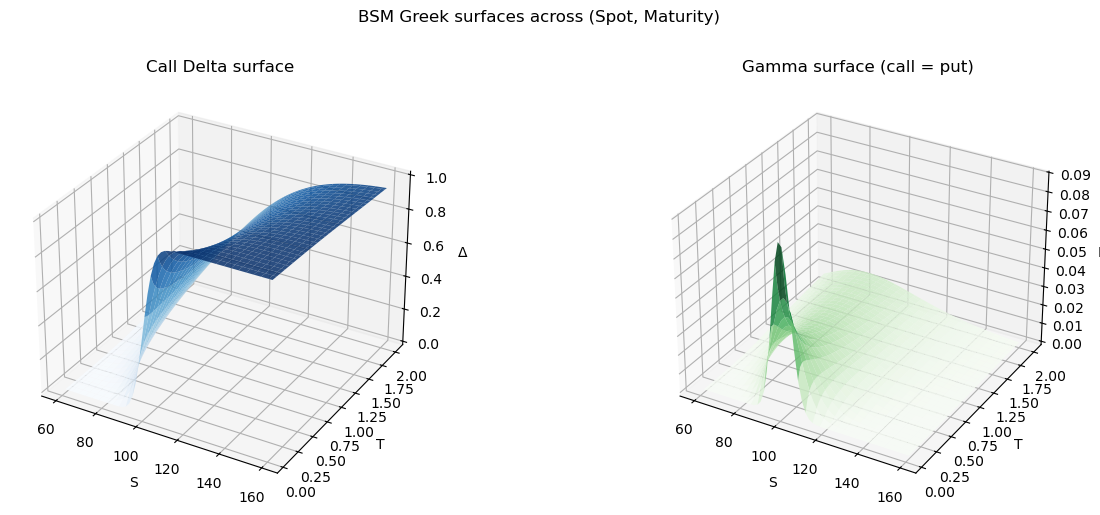

In [7]:
S_grid = np.linspace(60, 160, 60)
T_grid = np.linspace(0.05, 2.0, 60)
SS, TT = np.meshgrid(S_grid, T_grid)

DELTA = np.array([[bsm_delta(s, K, r, q, t, sigma) for s in S_grid] for t in T_grid])
GAMMA = np.array([[bsm_gamma(s, K, r, q, t, sigma) for s in S_grid] for t in T_grid])

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(SS, TT, DELTA, cmap='Blues', alpha=0.85)
ax1.set_xlabel('S'); ax1.set_ylabel('T'); ax1.set_zlabel('Δ')
ax1.set_title('Call Delta surface')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(SS, TT, GAMMA, cmap='Greens', alpha=0.85)
ax2.set_xlabel('S'); ax2.set_ylabel('T'); ax2.set_zlabel('Γ')
ax2.set_title('Gamma surface (call = put)')

plt.suptitle('BSM Greek surfaces across (Spot, Maturity)', y=1.01)
plt.tight_layout()
plt.show()